# 버추얼 아이돌 여론 분석 시각화

YouTube 댓글 데이터를 기반으로 버추얼 아이돌에 대한 사람들의 인식을 분석합니다.

## 1. 라이브러리 및 데이터 준비

In [ ]:
# 필요한 라이브러리 설치 (필요시 주석 해제)
# !pip install wordcloud matplotlib seaborn pandas numpy networkx

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
import platform
import ast
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    FONT = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    FONT = 'AppleGothic'
else:
    FONT = 'NanumGothic'

plt.rcParams['font.family'] = FONT
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# 차분한 색상 팔레트
COLORS = {
    'main': '#4A5568',       # 차콜 그레이
    'sub': '#718096',        # 미디엄 그레이
    'accent': '#63B3ED',     # 소프트 블루
    'light': '#E2E8F0',      # 라이트 그레이
    'text': '#2D3748',       # 다크 그레이
    'bg': '#FFFFFF'          # 화이트
}

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [32]:
# 토큰화된 CSV 파일 로드
df_raw = pd.read_csv('./data/Youtube_comment_01/raw/subsets/youtube_comments_N_A.csv')

# 문자열 리스트를 실제 리스트로 변환
def parse_keywords(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except:
        return []

tokenized_comments = df_raw['keywords'].apply(parse_keywords).tolist()
tokenized_comments = [t for t in tokenized_comments if len(t) > 0]

# 전체 단어 추출 및 빈도 계산
all_words = [word for tokens in tokenized_comments for word in tokens]
word_freq = Counter(all_words)

# DataFrame 생성
df_words = pd.DataFrame(word_freq.most_common(), columns=['단어', '빈도'])

print(f"분석 댓글 수: {len(tokenized_comments):,}개")
print(f"총 단어 수: {len(all_words):,}개")
print(f"고유 단어 수: {len(word_freq):,}개")
df_words.head(10)

분석 댓글 수: 4,777개
총 단어 수: 30,301개
고유 단어 수: 5,219개


,단어,빈도
0,있다,851
1,아니다,627
2,사람,565
3,좋다,470
4,없다,412
5,좋아하다,410
6,같다,388
7,노래,368
8,진짜,326
9,그렇다,307


## 2. 워드 클라우드 시각화

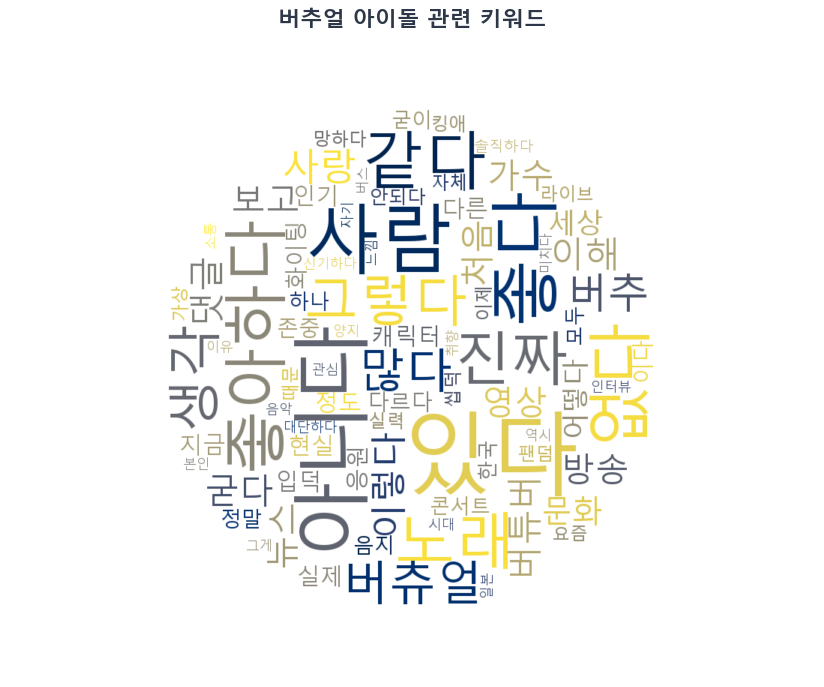

In [37]:
from wordcloud import WordCloud
from PIL import Image 
import numpy as np 


# 폰트 경로 설정
if platform.system() == 'Windows':
    font_path = 'C:/Windows/Fonts/malgun.ttf'
elif platform.system() == 'Darwin':
    font_path = '/System/Library/Fonts/AppleGothic.ttf'
else:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

image = Image.open("C:/Users/user/Pictures/circle.png") # ./images/heart.png
mask_img = np.array(image)

# 차분한 그레이 톤 워드클라우드
wc = WordCloud(
    font_path=font_path,
    width=1200,
    height=600,
    background_color='white',
    mask=mask_img,
    max_words=80,
    max_font_size=120,
    min_font_size=12,
    colormap='cividis',
    prefer_horizontal=0.7
)

wc.generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('버추얼 아이돌 관련 키워드', fontsize=16, fontweight='bold', 
             color=COLORS['text'], pad=15)

plt.tight_layout()
plt.savefig('01_wordcloud.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 3. 상위 키워드 빈도 분석

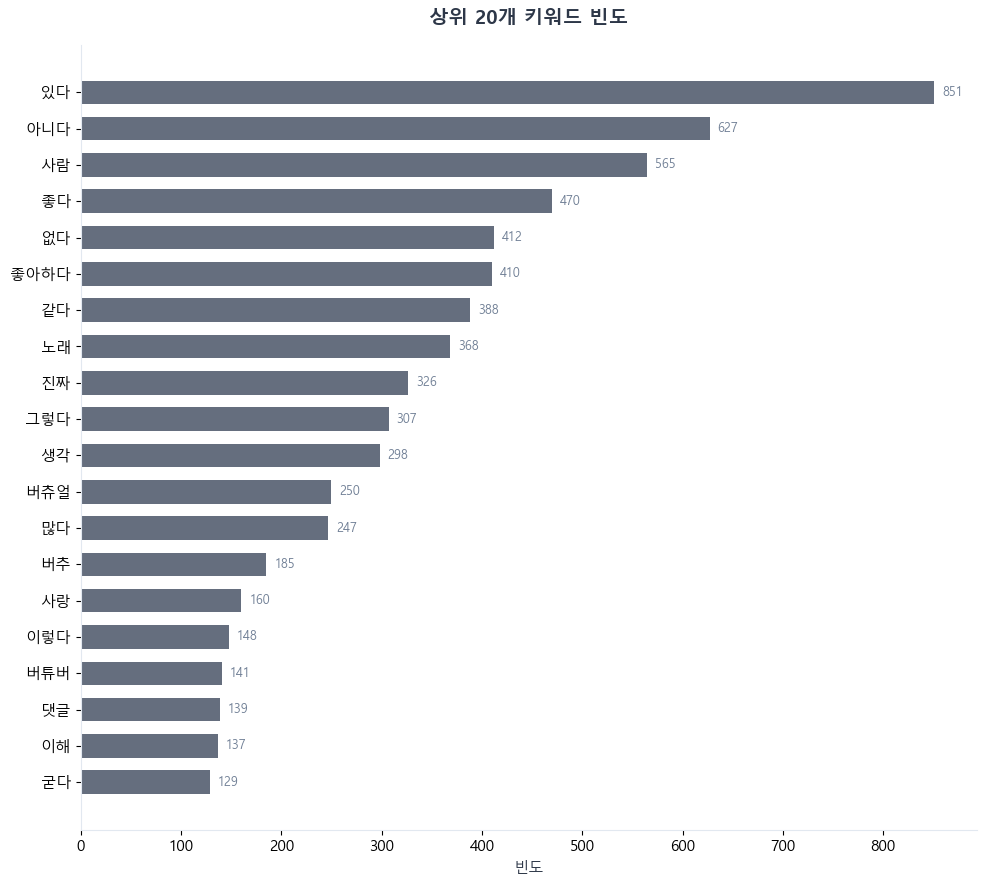

In [38]:
# 상위 20개 키워드
top20 = df_words.head(20)

fig, ax = plt.subplots(figsize=(10, 9))

y_pos = range(len(top20))
bars = ax.barh(y_pos, top20['빈도'].values[::-1], 
               color=COLORS['main'], height=0.65, alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(top20['단어'].values[::-1], fontsize=11)
ax.set_xlabel('빈도', fontsize=11, color=COLORS['text'])
ax.set_title('상위 20개 키워드 빈도', fontsize=14, fontweight='bold', 
             color=COLORS['text'], pad=15)

# 값 표시
for bar, val in zip(bars, top20['빈도'].values[::-1]):
    ax.text(val + 8, bar.get_y() + bar.get_height()/2, 
            f'{val}', va='center', fontsize=9, color=COLORS['sub'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(COLORS['light'])
ax.spines['bottom'].set_color(COLORS['light'])

plt.tight_layout()
plt.savefig('02_top_keywords.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 4. 카테고리별 분류

In [39]:
# 카테고리별 키워드 분류
categories = {
    '감정/평가': ['좋다', '좋아하다', '같다', '없다', '많다', '재밌다', '귀엽다', 
                '솔직하다', '안되다', '망하다', '다르다', '싫다', '이쁘다'],
    '인물/그룹': ['버튜버', '가수', '팬덤', '오빠', '멤버', '아티스트', '연예인', 
                '오타쿠', '씹덕', '팬', '사람'],
    '콘텐츠': ['노래', '댓글', '방송', '영상', '뉴스', '음악', '콘서트', '공연', 
             '무대', '라이브'],
    '문화/사회': ['세계', '문화', '현실', '한국', '일본', '존중', '취향', '덕질', 
               '세상', '사회']
}

# 카테고리별 빈도 합계
category_counts = {}
for cat, keywords in categories.items():
    total = sum(word_freq.get(kw, 0) for kw in keywords)
    category_counts[cat] = total

df_cat = pd.DataFrame(list(category_counts.items()), columns=['카테고리', '빈도'])
df_cat = df_cat.sort_values('빈도', ascending=False)

print("카테고리별 빈도:")
df_cat

카테고리별 빈도:


,카테고리,빈도
0,감정/평가,2367
2,콘텐츠,1132
1,인물/그룹,1127
3,문화/사회,652


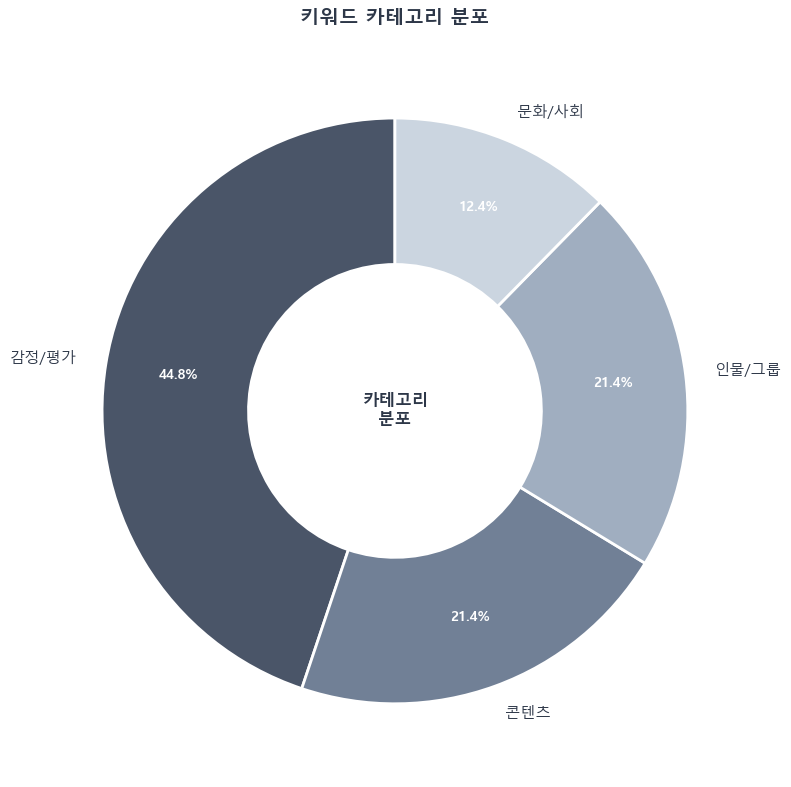

In [40]:
# 도넛 차트
fig, ax = plt.subplots(figsize=(10, 8))

# 차분한 색상
colors = ['#4A5568', '#718096', '#A0AEC0', '#CBD5E0']

wedges, texts, autotexts = ax.pie(
    df_cat['빈도'], 
    labels=df_cat['카테고리'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

for text in texts:
    text.set_fontsize(11)
    text.set_color(COLORS['text'])

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 중앙 텍스트
centre_circle = plt.Circle((0, 0), 0.35, fc='white')
ax.add_patch(centre_circle)
ax.text(0, 0, '카테고리\n분포', ha='center', va='center', 
        fontsize=12, color=COLORS['text'], fontweight='bold')

ax.set_title('키워드 카테고리 분포', fontsize=14, fontweight='bold', 
             color=COLORS['text'], pad=15)

plt.tight_layout()
plt.savefig('03_category_donut.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. 감성 분석

In [ ]:
# 감성 키워드 분류
positive_words = ['좋다', '좋아하다', '재밌다', '귀엽다', '사랑', '응원', 
                  '존중', '인기', '실력', '최고', '대단하다']
negative_words = ['없다', '안되다', '망하다', '조롱', '씹덕', '싫다', '이상하다', "불쾌", "불편"]
neutral_words = ['같다', '생각', '사람', '다르다', '이해', '문화', '정도']

positive_count = sum(word_freq.get(w, 0) for w in positive_words)
negative_count = sum(word_freq.get(w, 0) for w in negative_words)
neutral_count = sum(word_freq.get(w, 0) for w in neutral_words)
total = positive_count + negative_count + neutral_count

sentiment_data = {
    '감성': ['긍정', '중립', '부정'],
    '빈도': [positive_count, neutral_count, negative_count],
    '비율': [positive_count/total*100, neutral_count/total*100, negative_count/total*100]
}
df_sentiment = pd.DataFrame(sentiment_data)

print("감성 분석 결과:")
df_sentiment

감성 분석 결과:


,감성,빈도,비율
0,긍정,1548,39.279371
1,중립,1678,42.578026
2,부정,715,18.142603


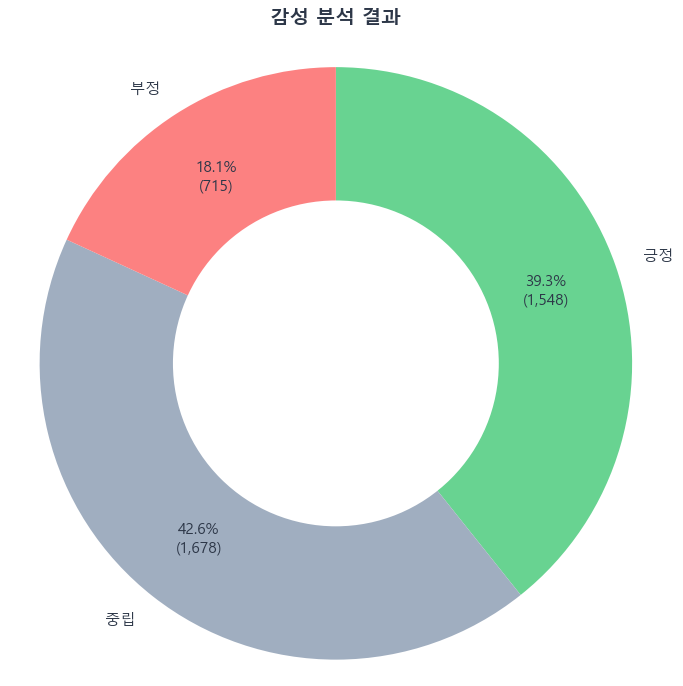

In [42]:
# 감성 분석 파이차트
fig, ax = plt.subplots(figsize=(7, 7))

colors_sentiment = ['#68D391', '#A0AEC0', '#FC8181']  # 긍정 / 중립 / 부정

def autopct_format(pct):
    total = df_sentiment['빈도'].sum()
    count = int(round(pct * total / 100.0))
    return f'{pct:.1f}%\n({count:,})'

wedges, texts, autotexts = ax.pie(
    df_sentiment['비율'],
    labels=df_sentiment['감성'],
    colors=colors_sentiment,
    startangle=90,
    counterclock=False,
    autopct=autopct_format,
    pctdistance=0.75,
    textprops={
        'fontsize': 11,
        'color': COLORS['text']
    }
)

# 도넛 스타일 (선택)
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax.add_artist(centre_circle)

ax.set_title(
    '감성 분석 결과',
    fontsize=14,
    fontweight='bold',
    color=COLORS['text'],
    pad=20
)

ax.axis('equal')  # 원형 유지

plt.tight_layout()
plt.savefig('04_sentiment_pie.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. 키워드 연관 네트워크

In [43]:
import networkx as nx
from itertools import combinations
from collections import defaultdict

# 동시출현 계산
min_freq = 5
vocab = {w for w, c in word_freq.items() if c >= min_freq}

cooccurrence = defaultdict(int)
for tokens in tokenized_comments:
    filtered = [t for t in set(tokens) if t in vocab]
    for w1, w2 in combinations(filtered, 2):
        pair = tuple(sorted([w1, w2]))
        cooccurrence[pair] += 1

# 상위 동시출현 쌍
top_pairs = sorted(cooccurrence.items(), key=lambda x: -x[1])[:60]

print(f"동시출현 단어쌍: {len(cooccurrence):,}개")

동시출현 단어쌍: 65,654개


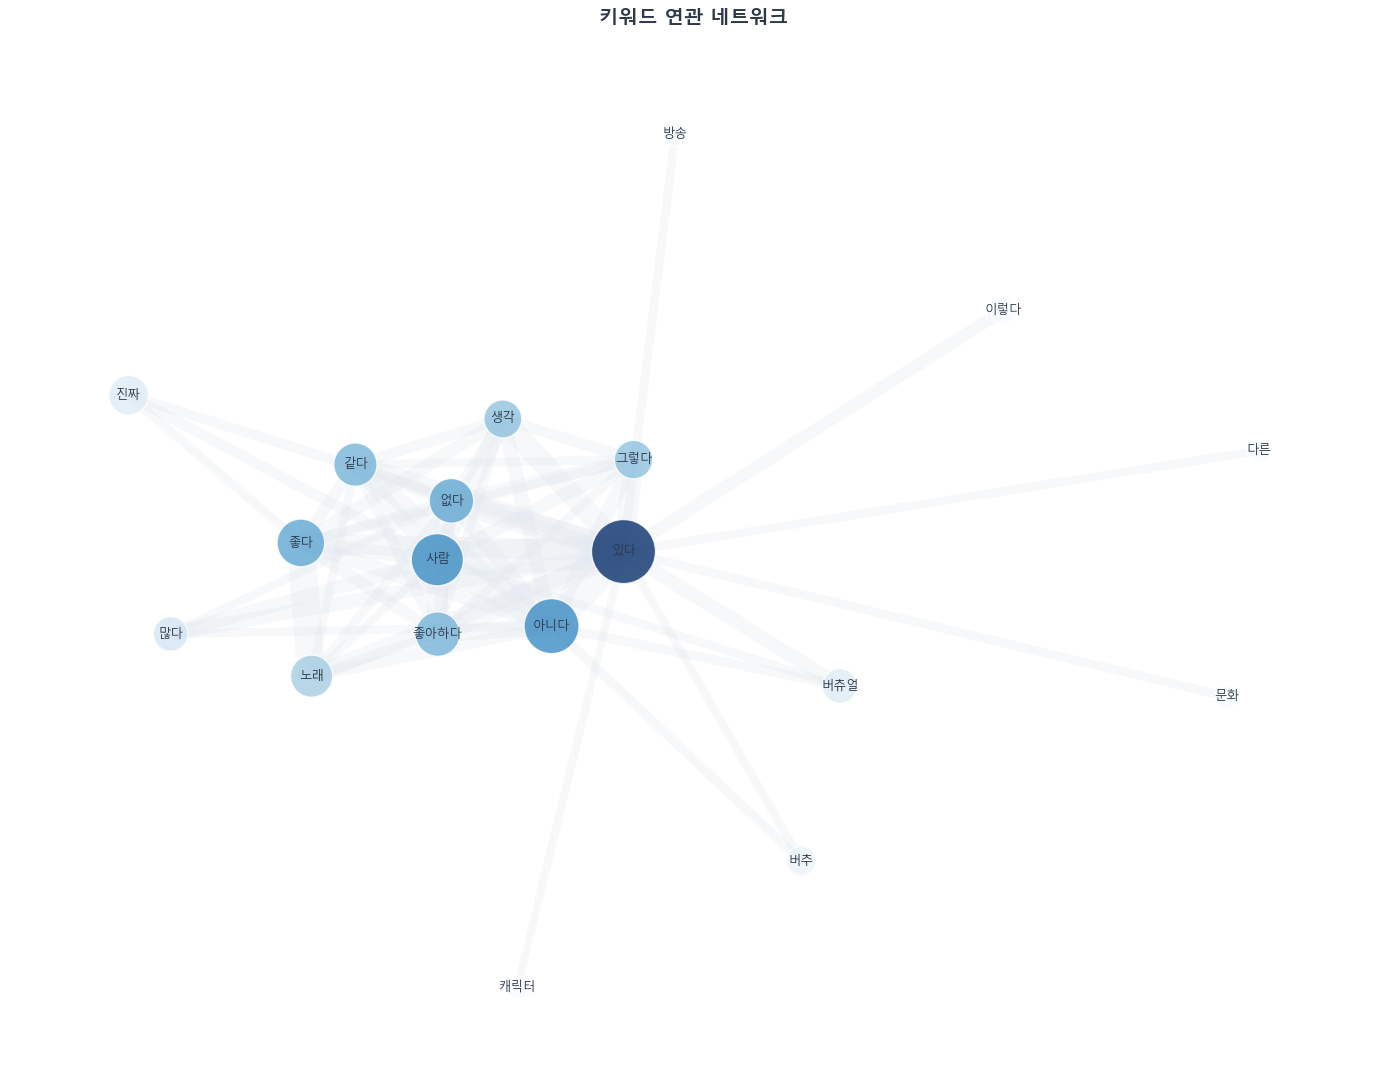

In [44]:
# 네트워크 생성
G = nx.Graph()
for (w1, w2), count in top_pairs:
    G.add_edge(w1, w2, weight=count)

fig, ax = plt.subplots(figsize=(14, 11))

pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# 노드 크기 (빈도 기반)
node_sizes = [word_freq.get(n, 10) * 2.5 for n in G.nodes()]

# 엣지 두께
edge_weights = [G[u][v]['weight'] * 0.15 for u, v in G.edges()]

# 노드 색상 (연결 정도 기반)
degrees = dict(G.degree())
node_colors = [degrees[n] for n in G.nodes()]

# 엣지 그리기
nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.3, 
                       edge_color=COLORS['light'], ax=ax)

# 노드 그리기
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                               node_color=node_colors, cmap=plt.cm.Blues,
                               alpha=0.8, edgecolors='white', linewidths=1, ax=ax)

# 레이블
nx.draw_networkx_labels(G, pos, font_size=9, font_color=COLORS['text'],
                        font_family=FONT, ax=ax)

ax.set_title('키워드 연관 네트워크', fontsize=14, fontweight='bold', 
             color=COLORS['text'], pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig('05_network.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. 핵심 키워드 TOP 10

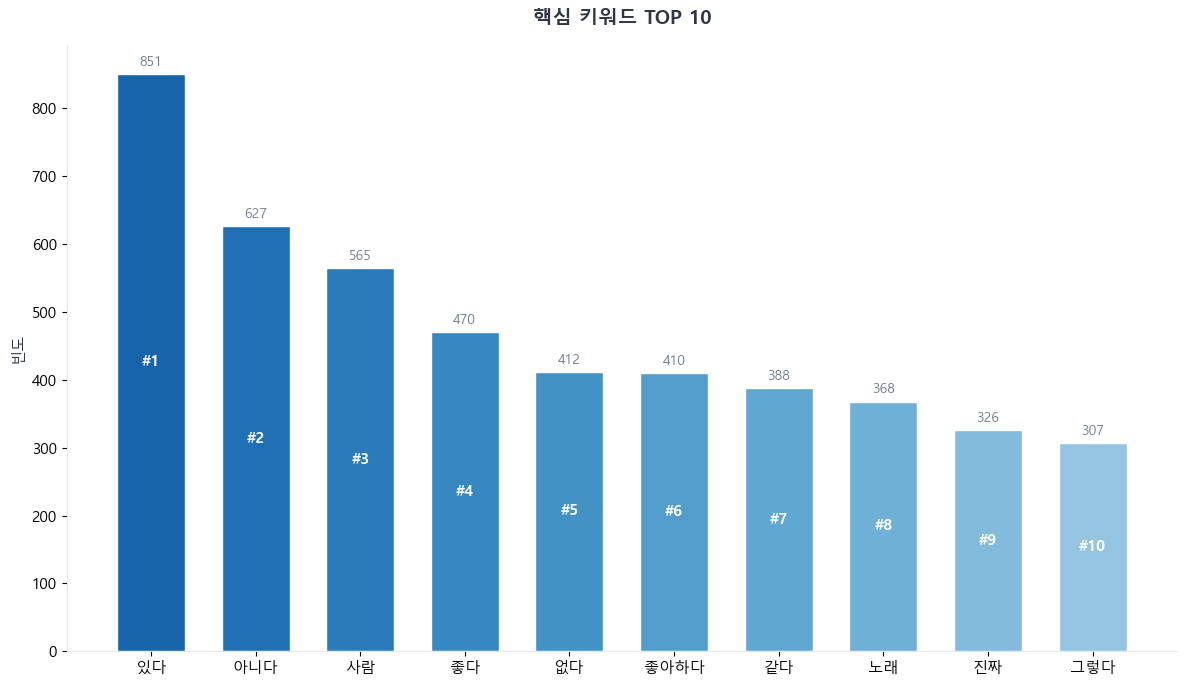

In [45]:
top10 = df_words.head(10)

fig, ax = plt.subplots(figsize=(12, 7))

# 그라데이션 효과 (같은 계열 색상)
colors_grad = plt.cm.Blues(np.linspace(0.4, 0.8, 10))[::-1]

bars = ax.bar(range(10), top10['빈도'], color=colors_grad, 
              width=0.65, edgecolor='white', linewidth=1)

# 순위 및 값 표시
for i, (bar, word, val) in enumerate(zip(bars, top10['단어'], top10['빈도'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 12, 
            f'{val}', ha='center', fontsize=10, color=COLORS['sub'])
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, 
            f'#{i+1}', ha='center', va='center', fontsize=11, 
            color='white', fontweight='bold')

ax.set_xticks(range(10))
ax.set_xticklabels(top10['단어'], fontsize=11)
ax.set_ylabel('빈도', fontsize=11, color=COLORS['text'])
ax.set_title('핵심 키워드 TOP 10', fontsize=14, fontweight='bold', 
             color=COLORS['text'], pad=15)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(COLORS['light'])
ax.spines['bottom'].set_color(COLORS['light'])

plt.tight_layout()
plt.savefig('06_top10.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 8. 종합 대시보드

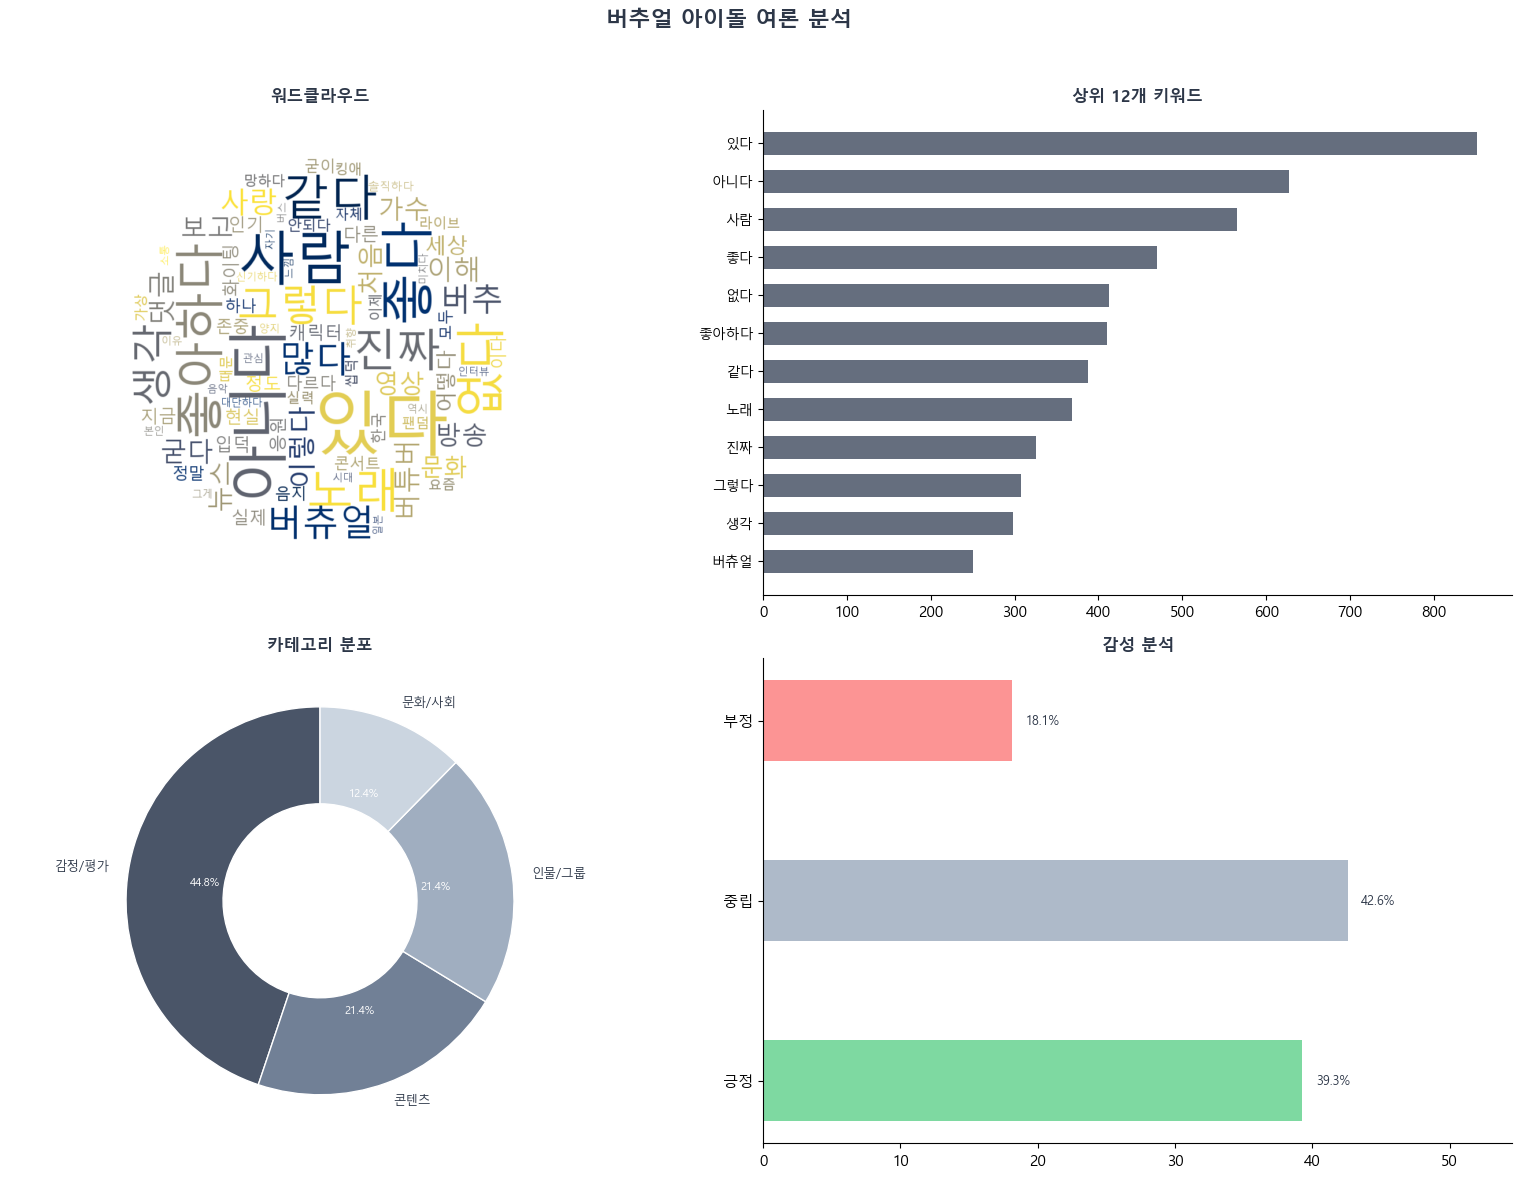

In [46]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('버추얼 아이돌 여론 분석', fontsize=16, fontweight='bold', 
             color=COLORS['text'], y=0.98)

# 1. 워드클라우드
ax1 = fig.add_subplot(2, 2, 1)
ax1.imshow(wc, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('워드클라우드', fontsize=12, fontweight='bold', color=COLORS['text'])

# 2. 상위 키워드
ax2 = fig.add_subplot(2, 2, 2)
top12 = df_words.head(12)
ax2.barh(range(12), top12['빈도'].values[::-1], color=COLORS['main'], height=0.6, alpha=0.85)
ax2.set_yticks(range(12))
ax2.set_yticklabels(top12['단어'].values[::-1], fontsize=10)
ax2.set_title('상위 12개 키워드', fontsize=12, fontweight='bold', color=COLORS['text'])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# 3. 카테고리 도넛
ax3 = fig.add_subplot(2, 2, 3)
colors_pie = ['#4A5568', '#718096', '#A0AEC0', '#CBD5E0']
wedges, texts, autotexts = ax3.pie(df_cat['빈도'], labels=df_cat['카테고리'],
                                    autopct='%1.1f%%', colors=colors_pie, startangle=90,
                                    wedgeprops=dict(width=0.5, edgecolor='white'))
for text in texts:
    text.set_fontsize(9)
    text.set_color(COLORS['text'])
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color('white')
ax3.set_title('카테고리 분포', fontsize=12, fontweight='bold', color=COLORS['text'])

# 4. 감성 분석
ax4 = fig.add_subplot(2, 2, 4)
colors_sent = ['#68D391', '#A0AEC0', '#FC8181']
ax4.barh(df_sentiment['감성'], df_sentiment['비율'], color=colors_sent, height=0.45, alpha=0.85)
for i, (pct, cnt) in enumerate(zip(df_sentiment['비율'], df_sentiment['빈도'])):
    ax4.text(pct + 1, i, f'{pct:.1f}%', va='center', fontsize=9, color=COLORS['text'])
ax4.set_xlim(0, max(df_sentiment['비율']) + 12)
ax4.set_title('감성 분석', fontsize=12, fontweight='bold', color=COLORS['text'])
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('07_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 9. 분석 결과 요약

In [47]:
print("="*55)
print("버추얼 아이돌 여론 분석 결과")
print("="*55)

print(f"\n[기본 통계]")
print(f"  분석 댓글 수: {len(tokenized_comments):,}개")
print(f"  총 단어 수: {len(all_words):,}개")
print(f"  고유 단어 수: {len(word_freq):,}개")

print(f"\n[핵심 키워드 TOP 10]")
for i, row in df_words.head(10).iterrows():
    print(f"  {i+1:2d}. {row['단어']} ({row['빈도']:,}회)")

print(f"\n[카테고리별 분포]")
for _, row in df_cat.iterrows():
    print(f"  {row['카테고리']}: {row['빈도']:,}회")

print(f"\n[감성 분석 결과]")
for _, row in df_sentiment.iterrows():
    print(f"  {row['감성']}: {row['비율']:.1f}% ({row['빈도']:,}회)")

print(f"\n[주요 인사이트]")
print(f"  1. 가장 많이 언급된 단어는 '{df_words.iloc[0]['단어']}'로 {df_words.iloc[0]['빈도']:,}회 등장")
print(f"  2. 감정/평가 관련 표현이 가장 높은 비중 차지")
print(f"  3. 긍정적 반응이 부정적 반응보다 높게 나타남")
print(f"  4. '버튜버', '팬덤' 등 커뮤니티 관련 키워드 다수 출현")

print("\n" + "="*55)

버추얼 아이돌 여론 분석 결과

[기본 통계]
  분석 댓글 수: 4,777개
  총 단어 수: 30,301개
  고유 단어 수: 5,219개

[핵심 키워드 TOP 10]
   1. 있다 (851회)
   2. 아니다 (627회)
   3. 사람 (565회)
   4. 좋다 (470회)
   5. 없다 (412회)
   6. 좋아하다 (410회)
   7. 같다 (388회)
   8. 노래 (368회)
   9. 진짜 (326회)
  10. 그렇다 (307회)

[카테고리별 분포]
  감정/평가: 2,367회
  콘텐츠: 1,132회
  인물/그룹: 1,127회
  문화/사회: 652회

[감성 분석 결과]
  긍정: 39.3% (1,548회)
  중립: 42.6% (1,678회)
  부정: 18.1% (715회)

[주요 인사이트]
  1. 가장 많이 언급된 단어는 '있다'로 851회 등장
  2. 감정/평가 관련 표현이 가장 높은 비중 차지
  3. 긍정적 반응이 부정적 반응보다 높게 나타남
  4. '버튜버', '팬덤' 등 커뮤니티 관련 키워드 다수 출현



---
### 저장된 파일
- `01_wordcloud.png` - 워드클라우드
- `02_top_keywords.png` - 상위 키워드 막대그래프
- `03_category_donut.png` - 카테고리별 도넛차트
- `04_sentiment.png` - 감성 분석 결과
- `05_network.png` - 키워드 연관 네트워크
- `06_top10.png` - TOP 10 키워드
- `07_dashboard.png` - 종합 대시보드